c:\Users\tunah\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Test seti boyutu: (1827, 17)
✅ SHAP hesaplandı. Base value (taban fiyat): 5.85 USD


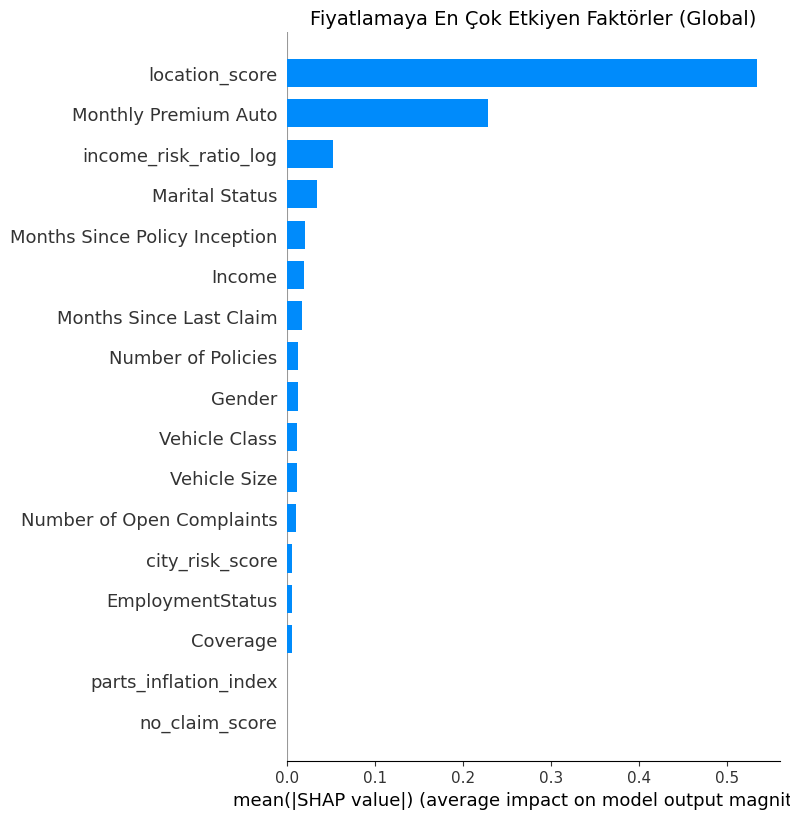

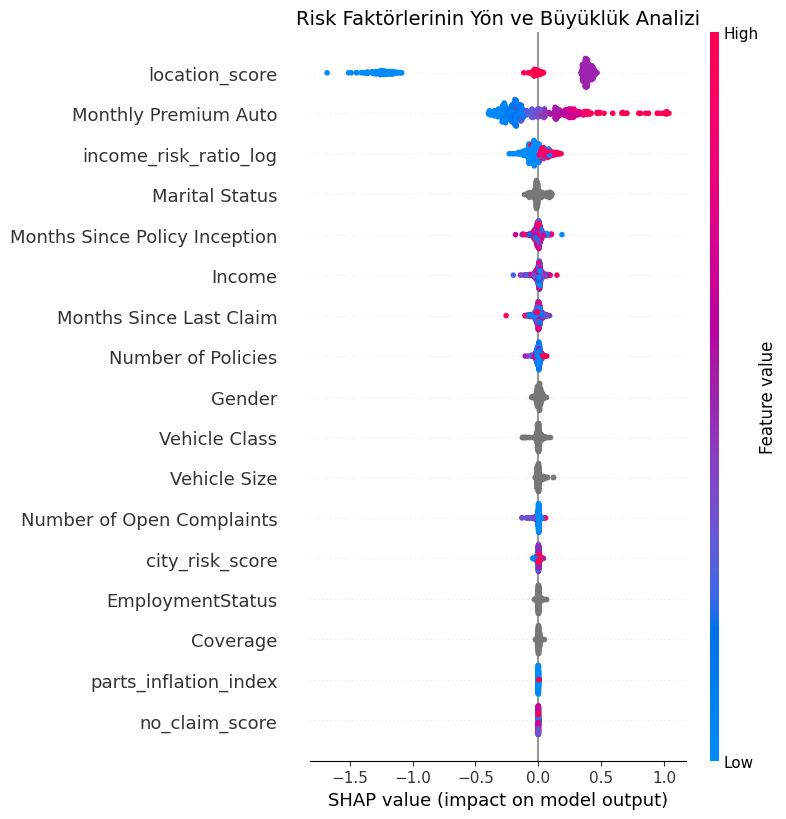


--- 10. Müşterinin Poliçe Fiyat Analizi ---
Monthly Premium Auto      93
city_risk_score            5
parts_inflation_index    1.0
no_claim_score             4
Name: 1010, dtype: object


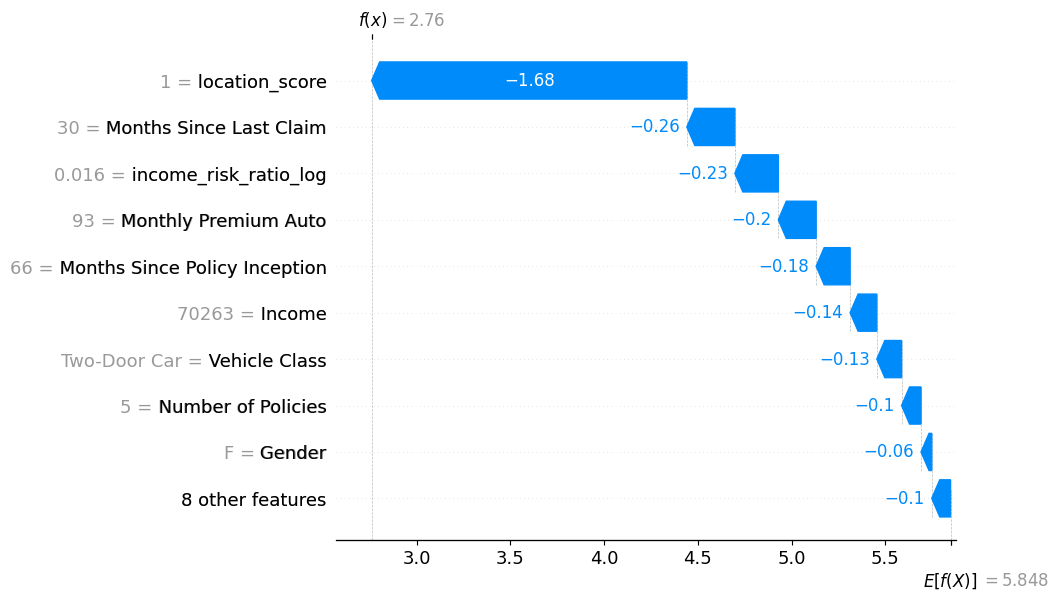

In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ============================================================
# 1. MODELİ VE VERİYİ YÜKLE
# ============================================================
model = joblib.load("../models/intelliprice_model.pkl")
df = pd.read_csv("../data/processed/intelliprice_featured.csv")

features = [
    'Monthly Premium Auto', 'Months Since Last Claim', 'Months Since Policy Inception',
    'Number of Open Complaints', 'Number of Policies', 'Income', 'city_risk_score',
    'parts_inflation_index', 'no_claim_score', 'income_risk_ratio_log',
    'location_score', 'Coverage', 'Vehicle Class', 'Vehicle Size',
    'EmploymentStatus', 'Marital Status', 'Gender'
]

cat_cols = ['Coverage', 'Vehicle Class', 'Vehicle Size', 
            'EmploymentStatus', 'Marital Status', 'Gender']

# Train/Test split — 03_model ile aynı random_state (42)
X = df[features].copy()
X[cat_cols] = X[cat_cols].astype('category')

_, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"✅ Test seti boyutu: {X_test.shape}")

# ============================================================
# 2. SHAP HESAPLA
# ============================================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:500])

print(f"✅ SHAP hesaplandı. Base value (taban fiyat): {explainer.expected_value:.2f} USD")

# ============================================================
# 3. GLOBAL: En Önemli Risk Faktörleri (Bar Plot)
# ============================================================
plt.figure(figsize=(10, 6))
plt.title("Fiyatlamaya En Çok Etkiyen Faktörler (Global)", fontsize=14)
shap.summary_plot(shap_values, X_test.iloc[:500], plot_type="bar", show=True)

# ============================================================
# 4. GLOBAL: Detaylı Dağılım (Beeswarm Plot)
# ============================================================
plt.figure(figsize=(10, 6))
plt.title("Risk Faktörlerinin Yön ve Büyüklük Analizi", fontsize=14)
shap.summary_plot(shap_values, X_test.iloc[:500], show=True)

# ============================================================
# 5. BİREYSEL: Tek Müşteri Analizi (Waterfall)
# ============================================================
musteri_index = 10

print(f"\n--- {musteri_index}. Müşterinin Poliçe Fiyat Analizi ---")
print(X_test.iloc[musteri_index][['Monthly Premium Auto', 'city_risk_score', 
                                   'parts_inflation_index', 'no_claim_score']])

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[musteri_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[musteri_index],
        feature_names=features
    )
)

In [1]:
pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 4.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 4.0 MB/s eta 0:00:10
   - -------------------------------------- 1.6/38.1 MB 4.3 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/38.1 MB 4.6 MB/s eta 0:00:08
   --- ------------------------------------ 3.4/38.1 MB 4.6 MB/s eta 0:00:08
   ---- ----------------------------------- 4.5/38.1 MB 4.3 MB/s eta 0:00:08
   ----- ---------------------------------- 5.2/38.1 MB 4.2 MB/s eta 0:00:08
   ------ --------------------------------- 5.8/38.1 MB 4.1 MB/s eta 0:00:08
   ------ --------------------------------- 6.6/38.1 MB 3.9 MB/s eta 0:00:09
   ------- -------------------------------- 7.1/38.1 MB 3.8 MB/s eta 0:00:09
   ------- -------------------------------- 7.6/38.1 MB 3.7 MB/s eta 0:00:09
   ------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
